Week 1 Task: Data Cleaning and Preliminary Analysis with R



In [1]:
# Step 1: Zaroori packages install krre
packages <- c("tidyverse", "ggplot2", "dplyr", "scales", "corrplot", "gridExtra")
new_pkgs <- packages[!(packages %in% installed.packages()[,"Package"])]
if(length(new_pkgs)) install.packages(new_pkgs, repos='https://cloud.r-project.org')

library(tidyverse)
library(ggplot2)
library(dplyr)
library(scales)
library(corrplot)
library(gridExtra)

cat("All packages successfully loaded!\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


corrplot 0.95 loaded


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




All packages successfully loaded!


In [2]:
# Step 2: Dataset ko direct cloud link se load krre
dataset_url <- "https://raw.githubusercontent.com/pplonski/datasets-for-start/master/employee_attrition/HR-Employee-Attrition-All.csv"
hr_data <- read.csv(dataset_url, stringsAsFactors = FALSE)

# Dataset ki dimensions (Rows x Columns)
cat("Dataset Dimensions (Rows, Columns):", dim(hr_data), "\n")

# Initial Structure aur pehle 5 rows
str(hr_data[, 1:10]) # Pehle 10 columns ka structure
head(hr_data, 5)

Dataset Dimensions (Rows, Columns): 1470 35 
'data.frame':	1470 obs. of  10 variables:
 $ Age             : int  41 49 37 33 27 32 59 30 38 36 ...
 $ Attrition       : chr  "Yes" "No" "Yes" "No" ...
 $ BusinessTravel  : chr  "Travel_Rarely" "Travel_Frequently" "Travel_Rarely" "Travel_Frequently" ...
 $ DailyRate       : int  1102 279 1373 1392 591 1005 1324 1358 216 1299 ...
 $ Department      : chr  "Sales" "Research & Development" "Research & Development" "Research & Development" ...
 $ DistanceFromHome: int  1 8 2 3 2 2 3 24 23 27 ...
 $ Education       : int  2 1 2 4 1 2 3 1 3 3 ...
 $ EducationField  : chr  "Life Sciences" "Life Sciences" "Other" "Life Sciences" ...
 $ EmployeeCount   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ EmployeeNumber  : int  1 2 4 5 7 8 10 11 12 13 ...


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,⋯,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
,<int>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,⋯,1,80,0,8,0,1,6,4,0,5
2,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,⋯,4,80,1,10,3,3,10,7,1,7
3,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,⋯,2,80,0,7,3,3,0,0,0,0
4,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,⋯,3,80,0,8,3,3,8,7,3,0
5,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,⋯,4,80,1,6,3,3,2,2,2,2


In [3]:
# Step 3: Missing values aur duplicates check krre
missing_vals <- colSums(is.na(hr_data))
cat("Total Missing Values in Dataset:", sum(missing_vals), "\n")
cat("Duplicate Rows:", sum(duplicated(hr_data)), "\n")

# Robust Imputation Function (Requirement #8 & #9 ke liye):
# Numeric missing values ko Median se aur Categorical ko Mode se fill krre hai
handle_missing_values <- function(data) {
  for(col_name in names(data)) {
    if(is.numeric(data[[col_name]])) {
      med_val <- median(data[[col_name]], na.rm = TRUE)
      data[[col_name]][is.na(data[[col_name]])] <- med_val
    } else {
      mode_val <- names(sort(table(data[[col_name]]), decreasing = TRUE))[1]
      data[[col_name]][is.na(data[[col_name]])] <- mode_val
    }
  }
  return(data)
}
hr_data <- handle_missing_values(hr_data)
cat("Data Quality check complete.\n")

Total Missing Values in Dataset: 0 
Duplicate Rows: 0 
Data Quality check complete.


In [4]:
# Step 4: Jin columns ki value sabhi ke liye same hai unhe drop karre
# EmployeeCount (always 1), Over18 (always Y), StandardHours (always 80), EmployeeNumber (ID)
redundant_cols <- c("EmployeeCount", "Over18", "StandardHours", "EmployeeNumber")
hr_clean <- hr_data %>% dplyr::select(-all_of(redundant_cols))

cat("Dimensions after removing redundant columns:", dim(hr_clean), "\n")

Dimensions after removing redundant columns: 1470 31 


In [5]:
# Step 5: Categorical columns ko Factors me convert karre
cat_cols <- c("Attrition", "BusinessTravel", "Department", "EducationField",
              "Gender", "JobRole", "MaritalStatus", "OverTime")
hr_clean[cat_cols] <- lapply(hr_clean[cat_cols], as.factor)

# Attrition ko quantitative rate calculation ke liye Binary me encode krre (Yes=1, No=0)
hr_clean$Attrition_Num <- ifelse(hr_clean$Attrition == "Yes", 1, 0)

# Feature Engineering:
# 1. Tenure Ratio: Total career me se kitna time current company me spend kra
hr_clean$TenureRatio <- round(hr_clean$YearsAtCompany / ifelse(hr_clean$TotalWorkingYears == 0, 1, hr_clean$TotalWorkingYears), 2)

# 2. Age Group Bucketing
hr_clean$AgeGroup <- cut(hr_clean$Age,
                         breaks = c(17, 30, 45, 65),
                         labels = c("Young (<30)", "Mid-Career (30-45)", "Senior (45+)"))

# 3. Composite Total Satisfaction Score
hr_clean$TotalSatisfaction <- hr_clean$EnvironmentSatisfaction +
                              hr_clean$JobSatisfaction +
                              hr_clean$RelationshipSatisfaction

cat("Feature engineering and factor encoding complete!\n")

Feature engineering and factor encoding complete!


In [6]:
# Step 6: IQR Method se MonthlyIncome ke Outliers detect karre
Q1 <- quantile(hr_clean$MonthlyIncome, 0.25)
Q3 <- quantile(hr_clean$MonthlyIncome, 0.75)
IQR_val <- Q3 - Q1
upper_limit <- Q3 + 1.5 * IQR_val
outliers_count <- sum(hr_clean$MonthlyIncome > upper_limit)

cat("MonthlyIncome Upper IQR Limit:", upper_limit, "\n")
cat("Number of High-Income Outliers:", outliers_count, "\n")

# Winsorization (95th percentile par capping)
cap_val <- quantile(hr_clean$MonthlyIncome, 0.95)
hr_clean$MonthlyIncome_Capped <- ifelse(hr_clean$MonthlyIncome > cap_val, cap_val, hr_clean$MonthlyIncome)

# Min-Max Normalization Function [0, 1]
min_max_scale <- function(x) { (x - min(x)) / (max(x) - min(x)) }
hr_clean$Income_Normalized <- min_max_scale(hr_clean$MonthlyIncome)

# Z-Score Standardization (Mean = 0, SD = 1)
hr_clean$Income_Standardized <- as.vector(scale(hr_clean$MonthlyIncome))

cat("Outlier treatment and normalization complete!\n")

MonthlyIncome Upper IQR Limit: 16581 
Number of High-Income Outliers: 114 
Outlier treatment and normalization complete!


In [7]:
# Step 7: Summary Statistics
cat("=== OVERALL STATISTICAL SUMMARY ===\n")
summary(hr_clean %>% dplyr::select(Age, MonthlyIncome, TotalWorkingYears, YearsAtCompany, DistanceFromHome))

# Department-wise Attrition Analysis
dept_summary <- hr_clean %>%
  group_by(Department) %>%
  summarise(
    Total_Employees = n(),
    Attrition_Count = sum(Attrition_Num),
    Attrition_Rate_Pct = round(mean(Attrition_Num) * 100, 2),
    Avg_Salary = round(mean(MonthlyIncome), 2)
  )
print(dept_summary)

# OverTime-wise Attrition Analysis
ot_summary <- hr_clean %>%
  group_by(OverTime) %>%
  summarise(
    Total = n(),
    Attrition_Count = sum(Attrition_Num),
    Attrition_Rate_Pct = round(mean(Attrition_Num) * 100, 2)
  )
print(ot_summary)

=== OVERALL STATISTICAL SUMMARY ===


      Age        MonthlyIncome   TotalWorkingYears YearsAtCompany  
 Min.   :18.00   Min.   : 1009   Min.   : 0.00     Min.   : 0.000  
 1st Qu.:30.00   1st Qu.: 2911   1st Qu.: 6.00     1st Qu.: 3.000  
 Median :36.00   Median : 4919   Median :10.00     Median : 5.000  
 Mean   :36.92   Mean   : 6503   Mean   :11.28     Mean   : 7.008  
 3rd Qu.:43.00   3rd Qu.: 8379   3rd Qu.:15.00     3rd Qu.: 9.000  
 Max.   :60.00   Max.   :19999   Max.   :40.00     Max.   :40.000  
 DistanceFromHome
 Min.   : 1.000  
 1st Qu.: 2.000  
 Median : 7.000  
 Mean   : 9.193  
 3rd Qu.:14.000  
 Max.   :29.000  

# A tibble: 3 × 5
  Department       Total_Employees Attrition_Count Attrition_Rate_Pct Avg_Salary
  <fct>                      <int>           <dbl>              <dbl>      <dbl>
1 Human Resources               63              12               19.0      6655.
2 Research & Deve…             961             133               13.8      6281.
3 Sales                        446              92               20.6      6959.
# A tibble: 2 × 4
  OverTime Total Attrition_Count Attrition_Rate_Pct
  <fct>    <int>           <dbl>              <dbl>
1 No        1054             110               10.4
2 Yes        416             127               30.5


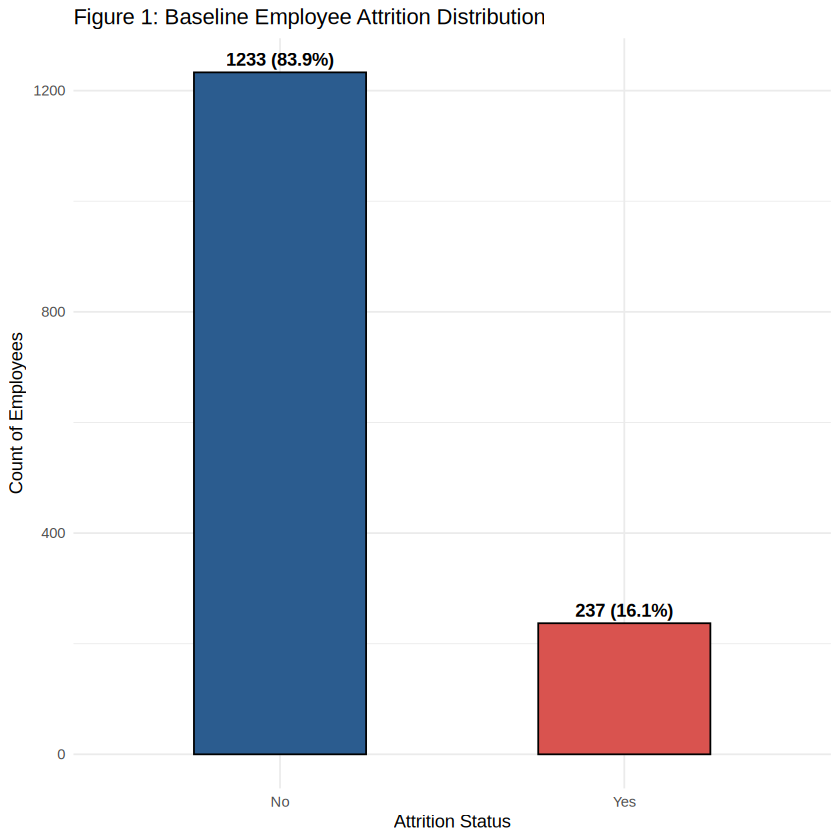

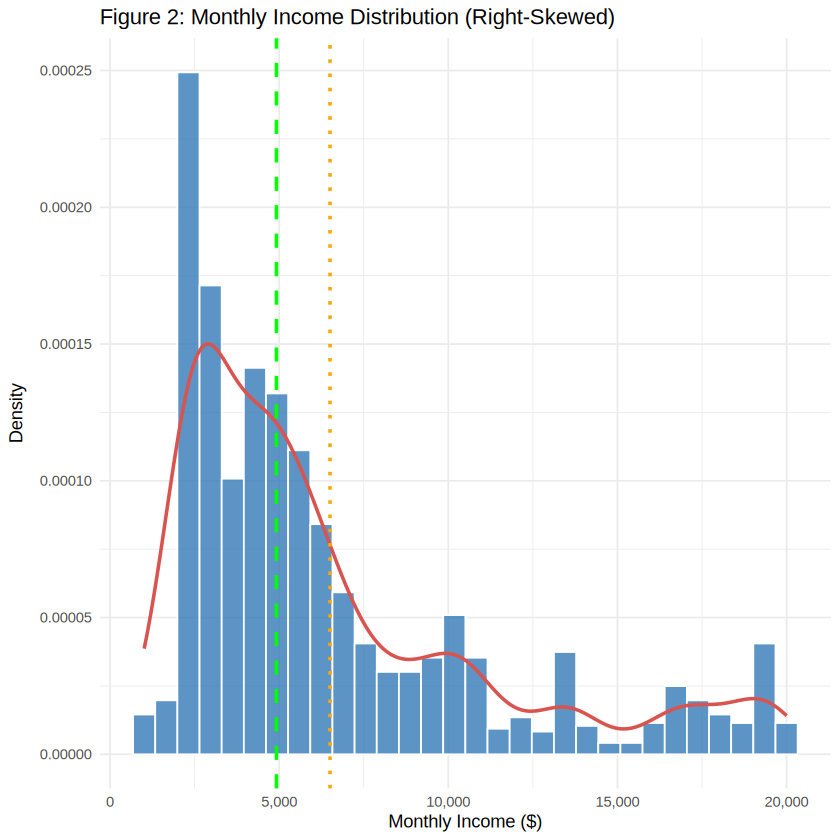

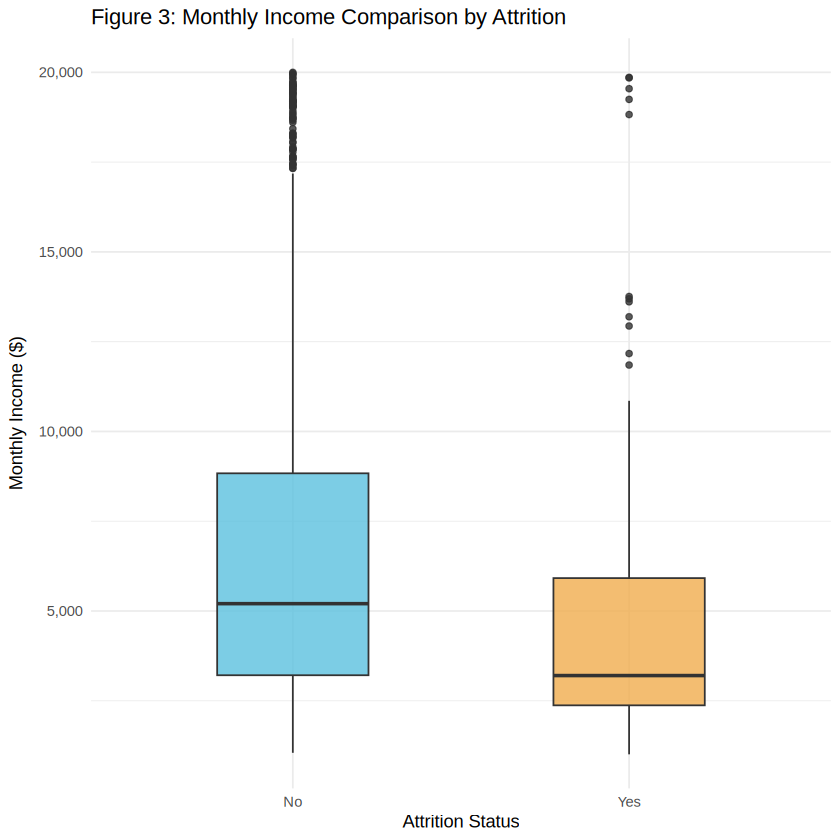

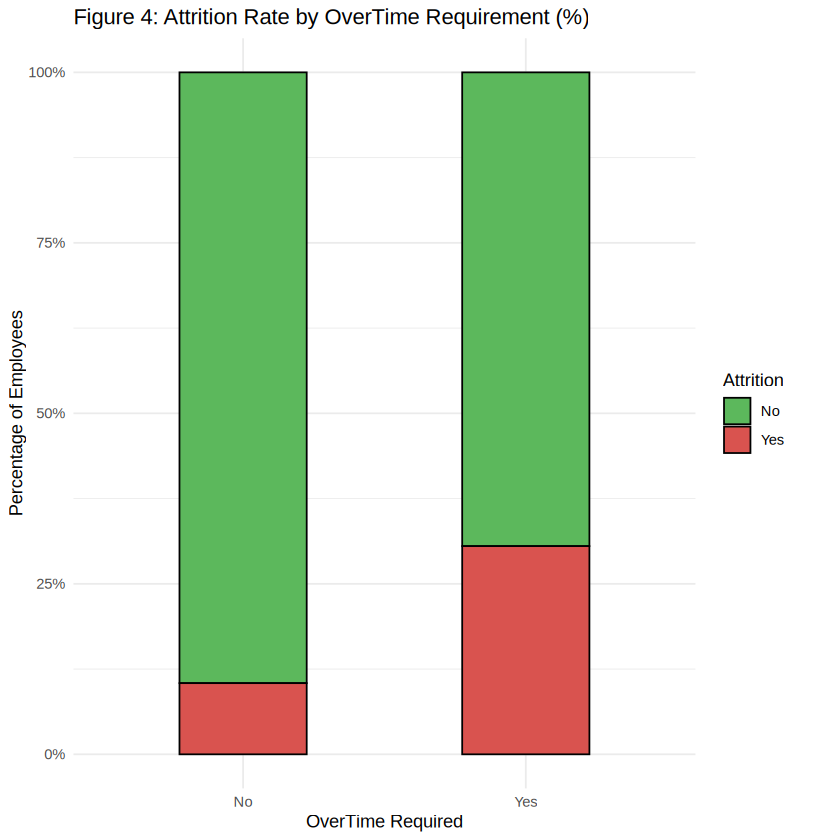

All steps executed and cleaned dataset exported!


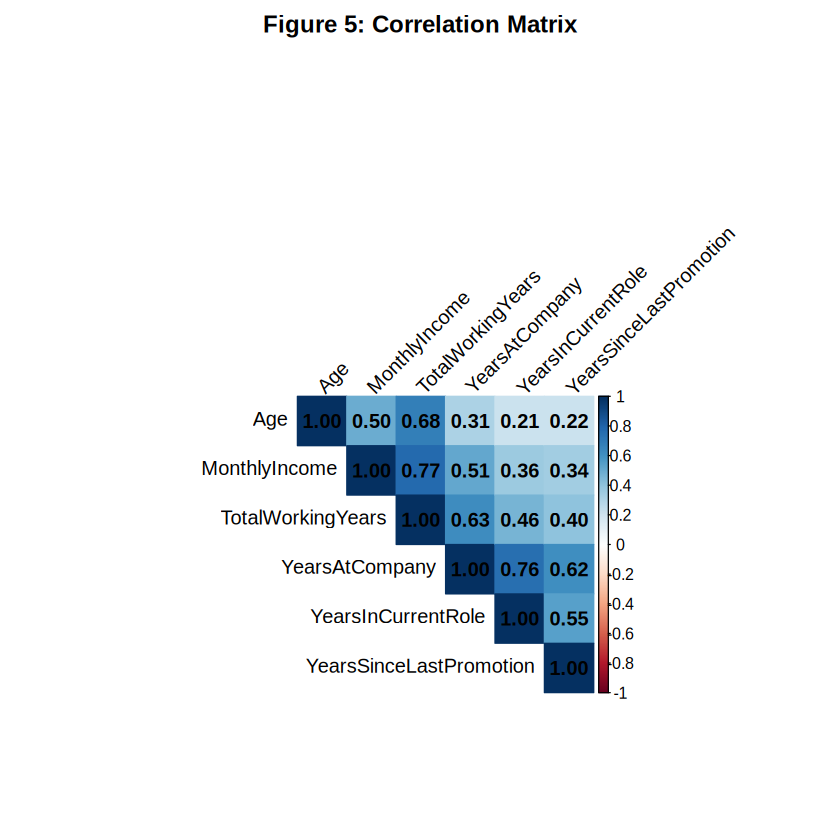

In [8]:
# Plot 1: Overall Attrition Distribution
p1 <- ggplot(hr_clean, aes(x = Attrition, fill = Attrition)) +
  geom_bar(width = 0.5, color = "black") +
  geom_text(stat = 'count', aes(label = paste0(after_stat(count), " (", round(after_stat(count)/nrow(hr_clean)*100, 1), "%)")), vjust = -0.5, fontface = "bold") +
  scale_fill_manual(values = c("No" = "#2b5c8f", "Yes" = "#d9534f")) +
  labs(title = "Figure 1: Baseline Employee Attrition Distribution", x = "Attrition Status", y = "Count of Employees") +
  theme_minimal() + theme(legend.position = "none")
print(p1)

# Plot 2: Monthly Income Distribution (Histogram + Density Curve)
p2 <- ggplot(hr_clean, aes(x = MonthlyIncome)) +
  geom_histogram(aes(y = after_stat(density)), bins = 30, fill = "#337ab7", color = "white", alpha = 0.8) +
  geom_density(color = "#d9534f", linewidth = 1) +
  geom_vline(aes(xintercept = median(MonthlyIncome)), color = "green", linetype = "dashed", linewidth = 1) +
  geom_vline(aes(xintercept = mean(MonthlyIncome)), color = "orange", linetype = "dotted", linewidth = 1) +
  scale_x_continuous(labels = comma) +
  labs(title = "Figure 2: Monthly Income Distribution (Right-Skewed)", x = "Monthly Income ($)", y = "Density") +
  theme_minimal()
print(p2)

# Plot 3: Boxplot of Income vs Attrition
p3 <- ggplot(hr_clean, aes(x = Attrition, y = MonthlyIncome, fill = Attrition)) +
  geom_boxplot(alpha = 0.8, width = 0.45) +
  scale_fill_manual(values = c("No" = "#5bc0de", "Yes" = "#f0ad4e")) +
  scale_y_continuous(labels = comma) +
  labs(title = "Figure 3: Monthly Income Comparison by Attrition", x = "Attrition Status", y = "Monthly Income ($)") +
  theme_minimal() + theme(legend.position = "none")
print(p3)

# Plot 4: Attrition Rate by OverTime
p4 <- ggplot(hr_clean, aes(x = OverTime, fill = Attrition)) +
  geom_bar(position = "fill", width = 0.45, color = "black") +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_manual(values = c("No" = "#5cb85c", "Yes" = "#d9534f")) +
  labs(title = "Figure 4: Attrition Rate by OverTime Requirement (%)", x = "OverTime Required", y = "Percentage of Employees") +
  theme_minimal()
print(p4)

# Plot 5: Correlation Heatmap of Numerical Features
num_cols <- hr_clean %>% dplyr::select(Age, MonthlyIncome, TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion)
corr_matrix <- cor(num_cols)
corrplot(corr_matrix, method = "color", addCoef.col = "black", tl.col = "black", tl.srt = 45, type = "upper", title = "Figure 5: Correlation Matrix", mar = c(0,0,2,0))

# Clean dataset export
write.csv(hr_clean, "IBM_HR_Cleaned_Dataset.csv", row.names = FALSE)
cat("All steps executed and cleaned dataset exported!\n")

Week 2 Task: Data Visualization and Insight Communication using R

In [9]:
# Step 1: Libraries load krre aur and reading IBM data
library(tidyverse)
library(ggplot2)
library(scales)
library(gridExtra)

url <- "https://raw.githubusercontent.com/pplonski/datasets-for-start/master/employee_attrition/HR-Employee-Attrition-All.csv"
hr_df <- read.csv(url, stringsAsFactors = FALSE)

hr_df$Attrition <- as.factor(hr_df$Attrition)
hr_df$JobRole <- as.factor(hr_df$JobRole)
hr_df$Department <- as.factor(hr_df$Department)
hr_df$EducationField <- as.factor(hr_df$EducationField)
cat("Dataset ready for Visualization!\n")

Dataset ready for Visualization!


`geom_smooth()` using formula = 'y ~ x'


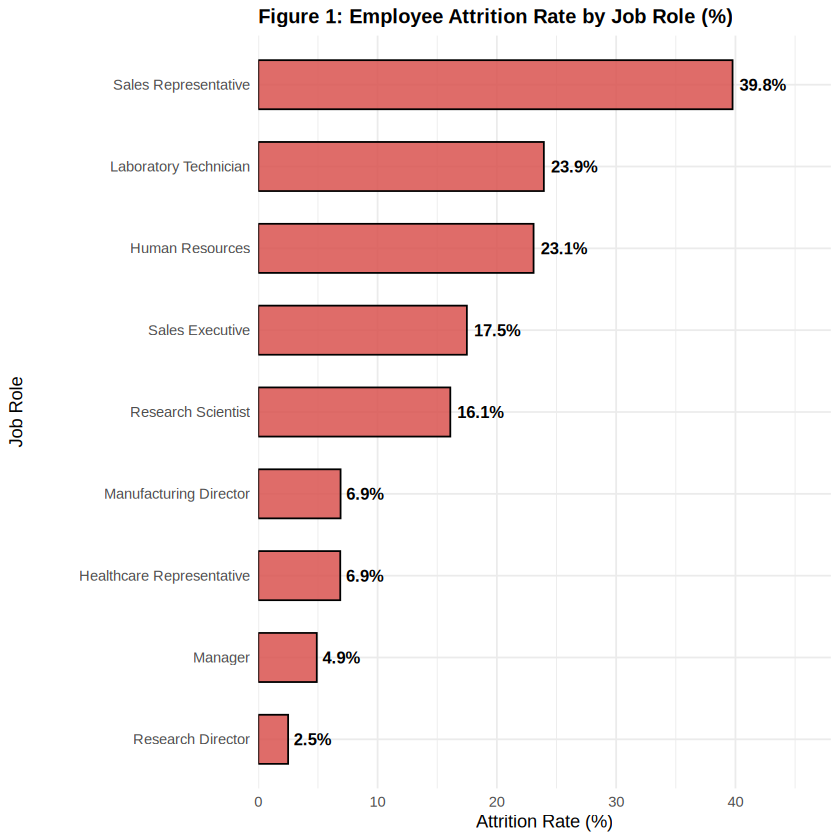

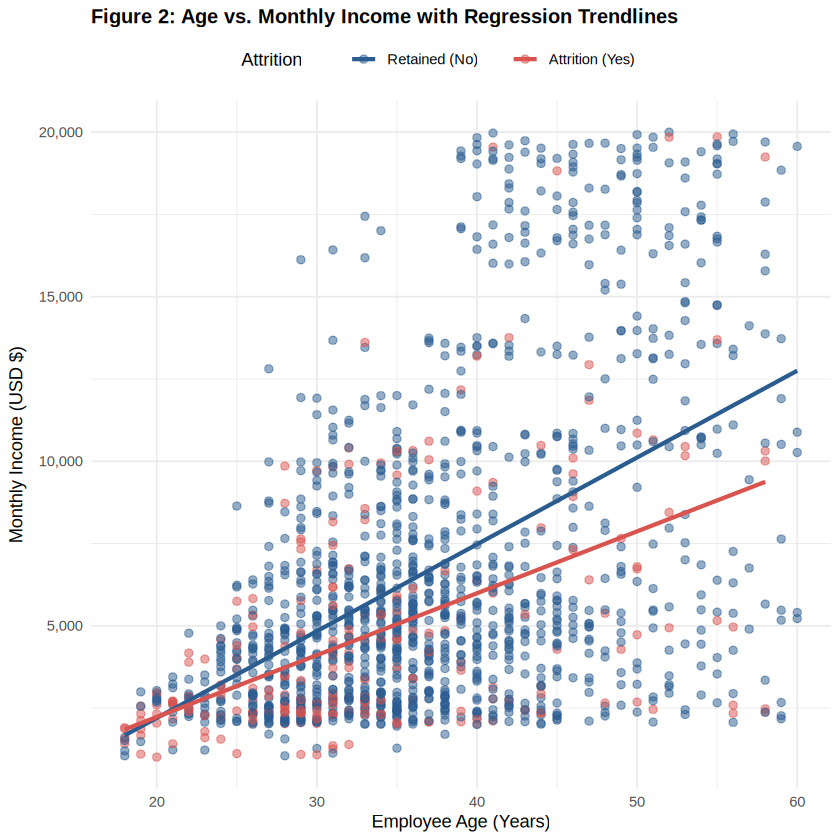

In [10]:
# --- VISUALIZATION 1: HORIZONTAL BAR CHART (Attrition by Job Role) ---
role_data <- hr_df %>%
  group_by(JobRole) %>%
  summarise(
    Total = n(),
    Attrition_Rate = mean(Attrition == "Yes") * 100
  ) %>%
  arrange(Attrition_Rate)

p1 <- ggplot(role_data, aes(x = reorder(JobRole, Attrition_Rate), y = Attrition_Rate)) +
  geom_bar(stat = "identity", fill = "#d9534f", color = "black", width = 0.6, alpha = 0.85) +
  geom_text(aes(label = paste0(round(Attrition_Rate, 1), "%")), hjust = -0.15, fontface = "bold", size = 3.5) +
  coord_flip() +
  scale_y_continuous(limits = c(0, 48), expand = c(0, 0)) +
  labs(title = "Figure 1: Employee Attrition Rate by Job Role (%)",
       x = "Job Role", y = "Attrition Rate (%)") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face = "bold", size = 12))
print(p1)

# --- VISUALIZATION 2: SCATTER PLOT WITH REGRESSION TRENDLINES (Age vs Income) ---
p2 <- ggplot(hr_df, aes(x = Age, y = MonthlyIncome, color = Attrition)) +
  geom_point(alpha = 0.5, size = 2) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 1.2) +
  scale_color_manual(values = c("No" = "#2b5c8f", "Yes" = "#d9534f"),
                     labels = c("Retained (No)", "Attrition (Yes)")) +
  scale_y_continuous(labels = comma) +
  labs(title = "Figure 2: Age vs. Monthly Income with Regression Trendlines",
       x = "Employee Age (Years)", y = "Monthly Income (USD $)") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face = "bold", size = 12), legend.position = "top")
print(p2)

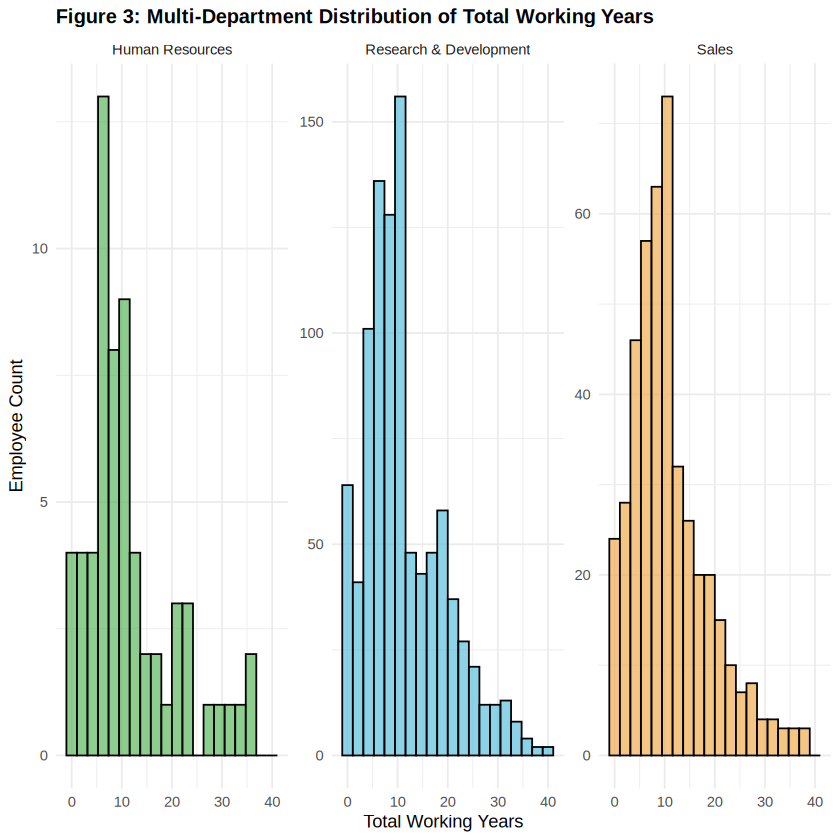

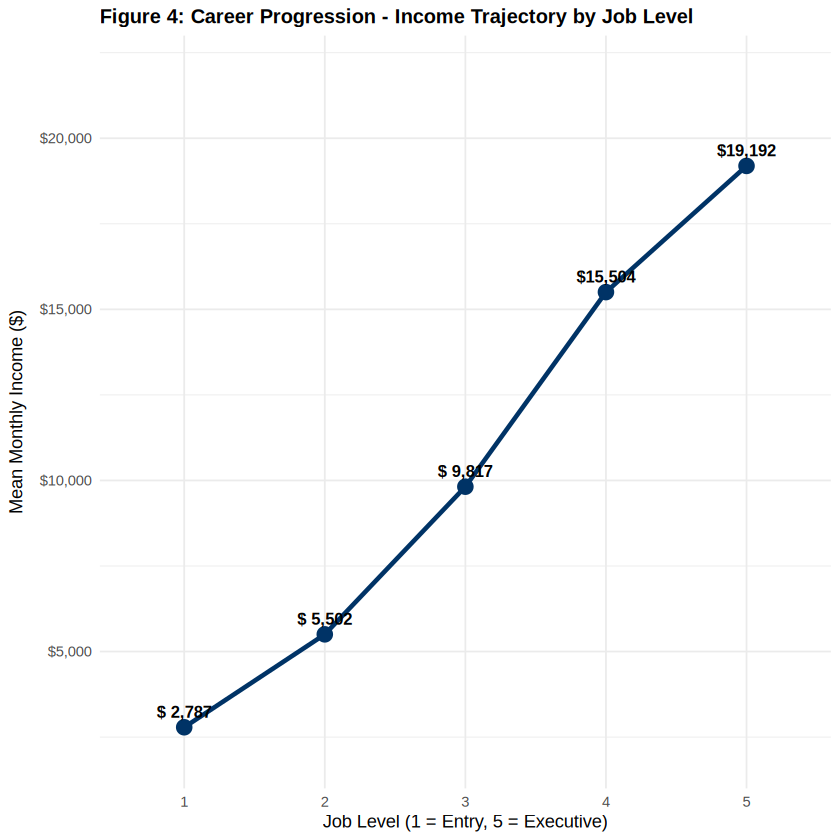

In [11]:
# --- VISUALIZATION 3: FACETED HISTOGRAMS (Working Experience by Department) ---
p3 <- ggplot(hr_df, aes(x = TotalWorkingYears, fill = Department)) +
  geom_histogram(bins = 20, color = "black", alpha = 0.7) +
  facet_wrap(~Department, scales = "free_y") +
  scale_fill_manual(values = c("Human Resources" = "#5cb85c", "Research & Development" = "#5bc0de", "Sales" = "#f0ad4e")) +
  labs(title = "Figure 3: Multi-Department Distribution of Total Working Years",
       x = "Total Working Years", y = "Employee Count") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face = "bold", size = 12), legend.position = "none")
print(p3)

# --- VISUALIZATION 4: LINE CHART (Career Ladder Salary Step-Up by Job Level) ---
ladder <- hr_df %>%
  group_by(JobLevel) %>%
  summarise(Mean_Income = mean(MonthlyIncome))

p4 <- ggplot(ladder, aes(x = factor(JobLevel), y = Mean_Income, group = 1)) +
  geom_line(color = "#003366", linewidth = 1.3) +
  geom_point(color = "#003366", size = 4) +
  geom_text(aes(label = paste0("$", format(round(Mean_Income), big.mark = ","))), vjust = -0.8, fontface = "bold", size = 3.5) +
  scale_y_continuous(labels = dollar, limits = c(2000, 22000)) +
  labs(title = "Figure 4: Career Progression - Income Trajectory by Job Level",
       x = "Job Level (1 = Entry, 5 = Executive)", y = "Mean Monthly Income ($)") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face = "bold", size = 12))
print(p4)

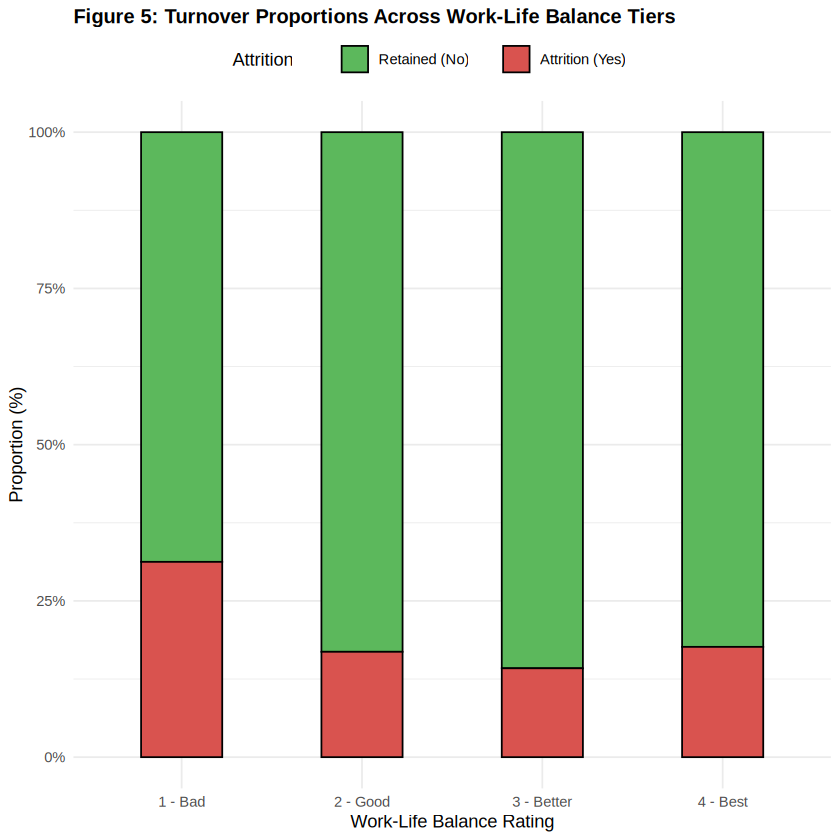

All Task 2 Visualizations successfully generated!


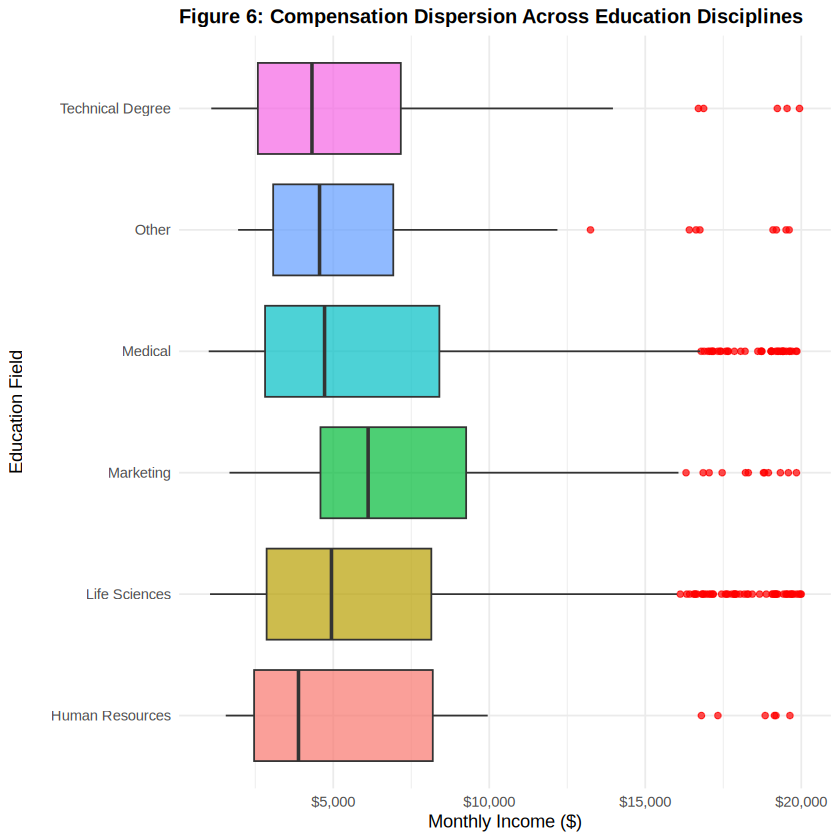

In [12]:
# --- VISUALIZATION 5: 100% STACKED BAR CHART (Work-Life Balance vs Attrition) ---
wlb_df <- hr_df %>%
  mutate(WLB_Desc = factor(WorkLifeBalance, levels = 1:4, labels = c("1 - Bad", "2 - Good", "3 - Better", "4 - Best")))

p5 <- ggplot(wlb_df, aes(x = WLB_Desc, fill = Attrition)) +
  geom_bar(position = "fill", width = 0.45, color = "black") +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_manual(values = c("No" = "#5cb85c", "Yes" = "#d9534f"),
                    labels = c("Retained (No)", "Attrition (Yes)")) +
  labs(title = "Figure 5: Turnover Proportions Across Work-Life Balance Tiers",
       x = "Work-Life Balance Rating", y = "Proportion (%)") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face = "bold", size = 12), legend.position = "top")
print(p5)

# --- VISUALIZATION 6: BOXPLOT (Compensation by Education Background) ---
p6 <- ggplot(hr_df, aes(x = EducationField, y = MonthlyIncome, fill = EducationField)) +
  geom_boxplot(alpha = 0.7, outlier.colour = "red", outlier.size = 1.5) +
  scale_y_continuous(labels = dollar) +
  coord_flip() +
  labs(title = "Figure 6: Compensation Dispersion Across Education Disciplines",
       x = "Education Field", y = "Monthly Income ($)") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face = "bold", size = 12), legend.position = "none")
print(p6)

cat("All Task 2 Visualizations successfully generated!\n")


Week 3 Task: Statistical Analysis and Predictive Modeling using R

In [13]:
# Step 1: Libraries install aur load krre
packages <- c("tidyverse", "caret", "pROC", "car", "gridExtra")
new_pkgs <- packages[!(packages %in% installed.packages()[,"Package"])]
if(length(new_pkgs)) install.packages(new_pkgs, repos='https://cloud.r-project.org')

library(tidyverse)
library(caret)
library(pROC)
library(car)
library(gridExtra)

url <- "https://raw.githubusercontent.com/pplonski/datasets-for-start/master/employee_attrition/HR-Employee-Attrition-All.csv"
hr_data <- read.csv(url, stringsAsFactors = FALSE)

hr_data$Attrition <- as.factor(hr_data$Attrition)
hr_data$OverTime <- as.factor(hr_data$OverTime)
hr_data$Department <- as.factor(hr_data$Department)

cat("Libraries and Dataset successfully loaded!\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘prodlim’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘recipes’, ‘reshape2’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Warning message in install.packages(new_pkgs, repos = "https://cloud.r-project.org"):
“installation of package ‘forecast’ had non-zero exit status”
Warning message in install.packages(new_pkgs, repos = "https://cloud.r-project.org"):
“installation of package ‘reformulas’ had non-zero exit status”
Warning message in install

ERROR: Error in library(caret): there is no package called ‘caret’


In [ ]:
# --- HYPOTHESIS 1: TWO-SAMPLE T-TEST (Monthly Income by Attrition) ---
cat("=== HYPOTHESIS 1: WELCH TWO-SAMPLE T-TEST ===\n")
t_res <- t.test(MonthlyIncome ~ Attrition, data = hr_data, var.equal = FALSE)
print(t_res)

# Non-parametric check (Mann-Whitney U / Wilcoxon Rank-Sum)
wilcox_res <- wilcox.test(MonthlyIncome ~ Attrition, data = hr_data)
print(wilcox_res)

# --- HYPOTHESIS 2: CHI-SQUARE TEST OF INDEPENDENCE (OverTime vs Attrition) ---
cat("\n=== HYPOTHESIS 2: CHI-SQUARE TEST OF INDEPENDENCE ===\n")
contingency_tab <- table(hr_data$OverTime, hr_data$Attrition)
chisq_res <- chisq.test(contingency_tab)
print(chisq_res)

# --- HYPOTHESIS 3: CORRELATION TEST (Tenure vs Income) ---
cat("\n=== HYPOTHESIS 3: CORRELATION TEST ===\n")
cor_res <- cor.test(hr_data$TotalWorkingYears, hr_data$MonthlyIncome)
print(cor_res)

In [ ]:
# --- STEP 3: TRAIN/TEST SPLIT (80/20 Stratified Partition) ---
set.seed(42)
train_idx <- createDataPartition(hr_data$Attrition, p = 0.80, list = FALSE)
train_df <- hr_data[train_idx, ]
test_df <- hr_data[-train_idx, ]

# Fit Multivariable Logistic Regression
logit_model <- glm(Attrition ~ Age + DistanceFromHome + EnvironmentSatisfaction +
                   JobInvolvement + JobLevel + JobSatisfaction + MonthlyIncome +
                   NumCompaniesWorked + OverTime + TotalWorkingYears +
                   YearsAtCompany + YearsInCurrentRole + YearsWithCurrManager +
                   WorkLifeBalance,
                   data = train_df, family = binomial)

summary(logit_model)

# Multicollinearity Check (VIF)
cat("=== VARIANCE INFLATION FACTORS (VIF) ===\n")
print(vif(logit_model))

# Odds Ratios [exp(beta)] and 95% Confidence Intervals
cat("\n=== LOGISTIC REGRESSION ODDS RATIOS ===\n")
odds_ratios <- exp(cbind(OR = coef(logit_model), confint.default(logit_model)))
print(round(odds_ratios, 3))

In [ ]:
# Test set par predictions
test_df$pred_prob <- predict(logit_model, newdata = test_df, type = "response")
test_df$pred_class <- as.factor(ifelse(test_df$pred_prob > 0.50, "Yes", "No"))

# Confusion Matrix
cm <- confusionMatrix(test_df$pred_class, test_df$Attrition, positive = "Yes")
print(cm)

# ROC Curve & Area Under the Curve (AUC)
roc_obj <- roc(test_df$Attrition, test_df$pred_prob)
auc_val <- auc(roc_obj)
cat("\nReceiver Operating Characteristic (ROC) AUC:", round(auc_val, 4), "\n")

# Plot ROC Curve
plot(roc_obj, col = "#003366", lwd = 3, main = paste0("ROC Curve (AUC = ", round(auc_val, 3), ")"))
abline(a = 0, b = 1, lty = 2, col = "gray")

In [ ]:
# Linear Regression for Continuous Outcome (Monthly Income)
lm_model <- lm(MonthlyIncome ~ TotalWorkingYears + JobLevel + Age + YearsAtCompany, data = hr_data)
summary(lm_model)

# Residual Diagnostic Plots (Residuals vs Fitted & Normal Q-Q)
par(mfrow = c(1, 2))
plot(lm_model, which = c(1, 2))
par(mfrow = c(1, 1))

cat("All models, hypothesis tests, and diagnostic evaluations complete!\n")

Week 4 Task: Comprehensive Data Analysis Reporting and Presentation

In [ ]:
install.packages("corrplot")

In [ ]:
# Step 1: Missing packages ko install aur load krre
if (!requireNamespace("corrplot", quietly = TRUE)) {
  install.packages("corrplot", repos = "https://cloud.r-project.org")
}
if (!requireNamespace("pROC", quietly = TRUE)) {
  install.packages("pROC", repos = "https://cloud.r-project.org")
}
if (!requireNamespace("caret", quietly = TRUE)) {
  install.packages("caret", repos = "https://cloud.r-project.org")
}

library(tidyverse)
library(caret)
library(pROC)
library(scales)
library(corrplot)

cat("Sabhi packages successfully load ho gaye hain!\n")

In [ ]:
url <- "https://raw.githubusercontent.com/pplonski/datasets-for-start/master/employee_attrition/HR-Employee-Attrition-All.csv"
hr_data <- read.csv(url, stringsAsFactors = FALSE)
cat("Dataset Ingested. Dimensions:", dim(hr_data), "\n")
# --- STEP 2: CONSOLIDATED DATA CLEANING & FEATURE ENGINEERING ---
# Redundant constant columns drop krre
redundant <- c("EmployeeCount", "Over18", "StandardHours", "EmployeeNumber")
hr_clean <- hr_data %>% dplyr::select(-all_of(redundant))
# Factors conversion aur Target variable encoding
cat_vars <- c("Attrition", "BusinessTravel", "Department", "EducationField",
              "Gender", "JobRole", "MaritalStatus", "OverTime")
hr_clean[cat_vars] <- lapply(hr_clean[cat_vars], as.factor)
hr_clean$Attrition_Binary <- ifelse(hr_clean$Attrition == "Yes", 1, 0)
# Feature Engineering
hr_clean$TenureRatio <- round(hr_clean$YearsAtCompany / ifelse(hr_clean$TotalWorkingYears == 0, 1, hr_clean$TotalWorkingYears), 2)
hr_clean$TotalSatisfaction <- hr_clean$EnvironmentSatisfaction + hr_clean$JobSatisfaction + hr_clean$RelationshipSatisfaction
# --- STEP 3: STATISTICAL HYPOTHESIS TESTING ---
cat("\n=== HYPOTHESIS 1: WELCH T-TEST ON MONTHLY INCOME ===\n")
print(t.test(MonthlyIncome ~ Attrition, data = hr_clean, var.equal = FALSE))
cat("\n=== HYPOTHESIS 2: CHI-SQUARE TEST: OVERTIME VS ATTRITION ===\n")
print(chisq.test(table(hr_clean$OverTime, hr_clean$Attrition)))
# --- STEP 4: PREDICTIVE LOGISTIC REGRESSION (80/20 STRATIFIED SPLIT) ---
set.seed(42)
train_idx <- createDataPartition(hr_clean$Attrition, p = 0.80, list = FALSE)
train_set <- hr_clean[train_idx, ]
test_set <- hr_clean[-train_idx, ]
logit_fit <- glm(Attrition ~ Age + DistanceFromHome + EnvironmentSatisfaction +
                 JobInvolvement + JobLevel + JobSatisfaction + MonthlyIncome +
                 NumCompaniesWorked + OverTime + TotalWorkingYears +
                 YearsAtCompany + YearsWithCurrManager + WorkLifeBalance,
                 data = train_set, family = binomial)
summary(logit_fit)
# --- STEP 5: EVALUATION, CONFUSION MATRIX & ROC-AUC ---
test_set$prob <- predict(logit_fit, newdata = test_set, type = "response")
test_set$pred <- as.factor(ifelse(test_set$prob > 0.50, "Yes", "No"))
cm <- confusionMatrix(test_set$pred, test_set$Attrition, positive = "Yes")
print(cm)
roc_res <- roc(test_set$Attrition, test_set$prob)
cat("\nFinal Capstone ROC-AUC Score:", round(auc(roc_res), 4), "\n")
# Multiple Linear Regression for Continuous Wage Model
lm_comp <- lm(MonthlyIncome ~ TotalWorkingYears + JobLevel + Age, data = hr_clean)
cat("Multiple Linear Regression R-Squared:", summary(lm_comp)$r.squared, "\n")
cat("\n=== MASTER CAPSTONE PIPELINE EXECUTED SUCCESSFULLY! ===\n")